Objetivos sugeridos:

--  Produtos mais vendidos por quantidade e receita.
     
     --- puxar por ordem crescente as vendas totais de cada produto e total da receita - faturamento

--  Análise por estado e cidade

    --- puxar vendas por estado e rankear os mais vendidos de cada estado e cidade posteriormente

-- Tendência mensal de vendas.

    --- analisar a tendencia de vendas mensais e analisar meses que tem mais vendas e menos vendas 

-- Visualizações com matplotlib e seaborn.

In [108]:
import pandas as pd  

df = pd.read_csv("sales_data_com_estado.csv", encoding="cp1252")
display(df)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,Grand Est,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,ÃŽle-de-France,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,Community of Madrid,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,NaN,Oulu,North Ostrobothnia,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,Community of Madrid,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,NaN,Toulouse,Occitanie,31000,France,EMEA,Roulet,Annette,Small


In [109]:
import plotly.express as px
import plotly.graph_objects as pg  
import matplotlib.pyplot as plt

In [110]:
pd.set_option('display.max_columns', None)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


None

In [111]:

display(df)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,Grand Est,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,ÃŽle-de-France,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,Community of Madrid,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,Ships,54,S72_3212,"Oulu Toy Supplies, Inc.",981-443655,Torikatu 38,NaN,Oulu,North Ostrobothnia,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,Ships,54,S72_3212,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,Community of Madrid,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,Ships,54,S72_3212,Alpha Cognac,61.77.6555,1 rue Alsace-Lorraine,NaN,Toulouse,Occitanie,31000,France,EMEA,Roulet,Annette,Small


#   Produtos mais vendidos por quantidade e receita.
     
     --- puxar por ordem crescente as vendas totais de cada produto e total da receita - faturamento

In [112]:
df.sort_values(by="SALES")

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
2249,10425,11,43.83,6,482.13,5/31/2005 0:00,In Process,2,5,2005,Trucks and Buses,54,S32_2509,La Rochelle Gifts,40.67.8555,"67, rue des Cinquante Otages",NaN,Nantes,Pays de la Loire,44000,France,EMEA,Labrune,Janine,Small
1287,10407,6,90.19,3,541.14,4/22/2005 0:00,On Hold,2,4,2005,Vintage Cars,92,S18_4409,The Sharp Gifts Warehouse,4085553659,3086 Ingle Ln.,NaN,San Jose,CA,94217,USA,NaN,Frick,Sue,Small
2044,10408,15,36.93,1,553.95,4/22/2005 0:00,Shipped,2,4,2005,Vintage Cars,41,S24_3969,"Tokyo Collectables, Ltd",+81 3 3584 0555,2-2-8 Roppongi,NaN,Minato-ku,Tokyo,106-0032,Japan,Japan,Shimamura,Akiko,Small
1551,10280,20,28.88,12,577.60,8/17/2004 0:00,Shipped,3,8,2004,Vintage Cars,33,S24_1937,Amica Models & Co.,011-4988555,Via Monte Bianco 34,NaN,Torino,Piedmont,10100,Italy,EMEA,Accorti,Paolo,Small
1818,10419,15,42.67,7,640.05,5/17/2005 0:00,Shipped,2,5,2005,Classic Cars,37,S24_2972,Salzburg Collectables,6562-9555,Geislweg 14,NaN,Salzburg,Salzburg,5020,Austria,EMEA,Pipps,Georg,Small
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,10403,66,100.00,9,11886.60,4/8/2005 0:00,Shipped,2,4,2005,Motorcycles,193,S10_4698,"UK Collectables, Ltd.",(171) 555-2282,Berkeley Gardens 12 Brewery,NaN,Liverpool,Merseyside,WX1 6LT,UK,EMEA,Devon,Elizabeth,Large
1062,10412,60,100.00,9,11887.80,5/3/2005 0:00,Shipped,2,5,2005,Classic Cars,169,S18_3232,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,Community of Madrid,28034,Spain,EMEA,Freyre,Diego,Large
53,10424,50,100.00,6,12001.00,5/31/2005 0:00,In Process,2,5,2005,Classic Cars,214,S10_1949,Euro Shopping Channel,(91) 555 94 44,"C/ Moralzarzal, 86",NaN,Madrid,Community of Madrid,28034,Spain,EMEA,Freyre,Diego,Large
744,10322,50,100.00,6,12536.50,11/4/2004 0:00,Shipped,4,11,2004,Vintage Cars,127,S18_2325,Online Diecast Creations Co.,6035558647,2304 Long Airport Avenue,NaN,Nashua,NH,62005,USA,NaN,Young,Valarie,Large


In [113]:
# agrupa por linha de produto e calcula total de quantidade e receita

agrupado = df.groupby("PRODUCTLINE").agg({
    "QUANTITYORDERED":"sum",
    "SALES":"sum"
}).reset_index()

# ordernar por receita em ordem crescente
agrupado_ordenado = agrupado.sort_values(by="SALES", ascending=True)
display(agrupado_ordenado)

,PRODUCTLINE,QUANTITYORDERED,SALES
4,Trains,2712,226243.47
3,Ships,8127,714437.13
2,Planes,10727,975003.57
5,Trucks and Buses,10777,1127789.84
1,Motorcycles,11663,1166388.34
6,Vintage Cars,21069,1903150.84
0,Classic Cars,33992,3919615.66


In [146]:
df.to_excel("agrupado_ordenado.xlsx", index=False)


In [114]:
percento = agrupado_ordenado['SALES'].sum()
display(percento)

np.float64(10032628.85)

C:\Users\amand\AppData\Local\Temp\ipykernel_17596\3108354412.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(produto, rotation=45)  # Rotaciona os nomes no eixo X


[Text(0, 0, 'Trains'),
 Text(1, 0, 'Ships'),
 Text(2, 0, 'Planes'),
 Text(3, 0, 'Trucks and Buses'),
 Text(4, 0, 'Motorcycles'),
 Text(5, 0, 'Vintage Cars'),
 Text(6, 0, 'Classic Cars')]

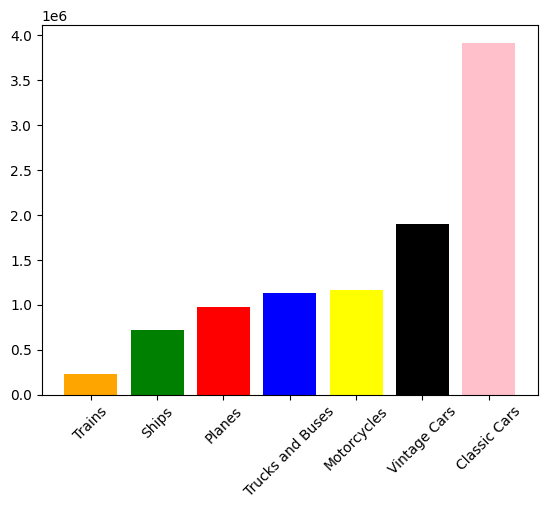

In [115]:
fig, ax = plt.subplots()
receita = agrupado_ordenado["SALES"]
produto = agrupado_ordenado["PRODUCTLINE"]
bar_colors = ['orange','green','red','blue','yellow','black','pink']

ax.bar(produto, receita, color=bar_colors)
ax.set_xticklabels(produto, rotation=45)  # Rotaciona os nomes no eixo X


# entao...
-- vimos que na receita total temos que classic cars é o produto mais vendido seguido dos vintage cars e motorcycles, nosso top 3

In [116]:
agrupado_por_estado = df.groupby("STATE")["SALES"].sum().reset_index()
# display(agrupado_por_estado)
porcentagem_estado = agrupado_por_estado
porcentagem_estado['PERCENTAGE'] = (agrupado_por_estado['SALES']/agrupado_por_estado['SALES'].sum()) * 100
display(porcentagem_estado)

,STATE,SALES,PERCENTAGE
0,Andalusia,54723.62,0.545456
1,Auvergne-RhÃ´ne-Alpes,142874.25,1.424096
2,BC,149873.77,1.493863
3,Bavaria,34993.92,0.348801
4,Brussels-Capital,74972.52,0.747287
5,CA,1505542.23,15.006458
6,CT,238661.28,2.378851
7,Capital Region,145041.60,1.445699
8,Catalonia,78411.86,0.781568
9,Central Denmark Region,100595.55,1.002684


In [147]:
df.to_excel("agrupado_por_estado.xlsx", index=False)


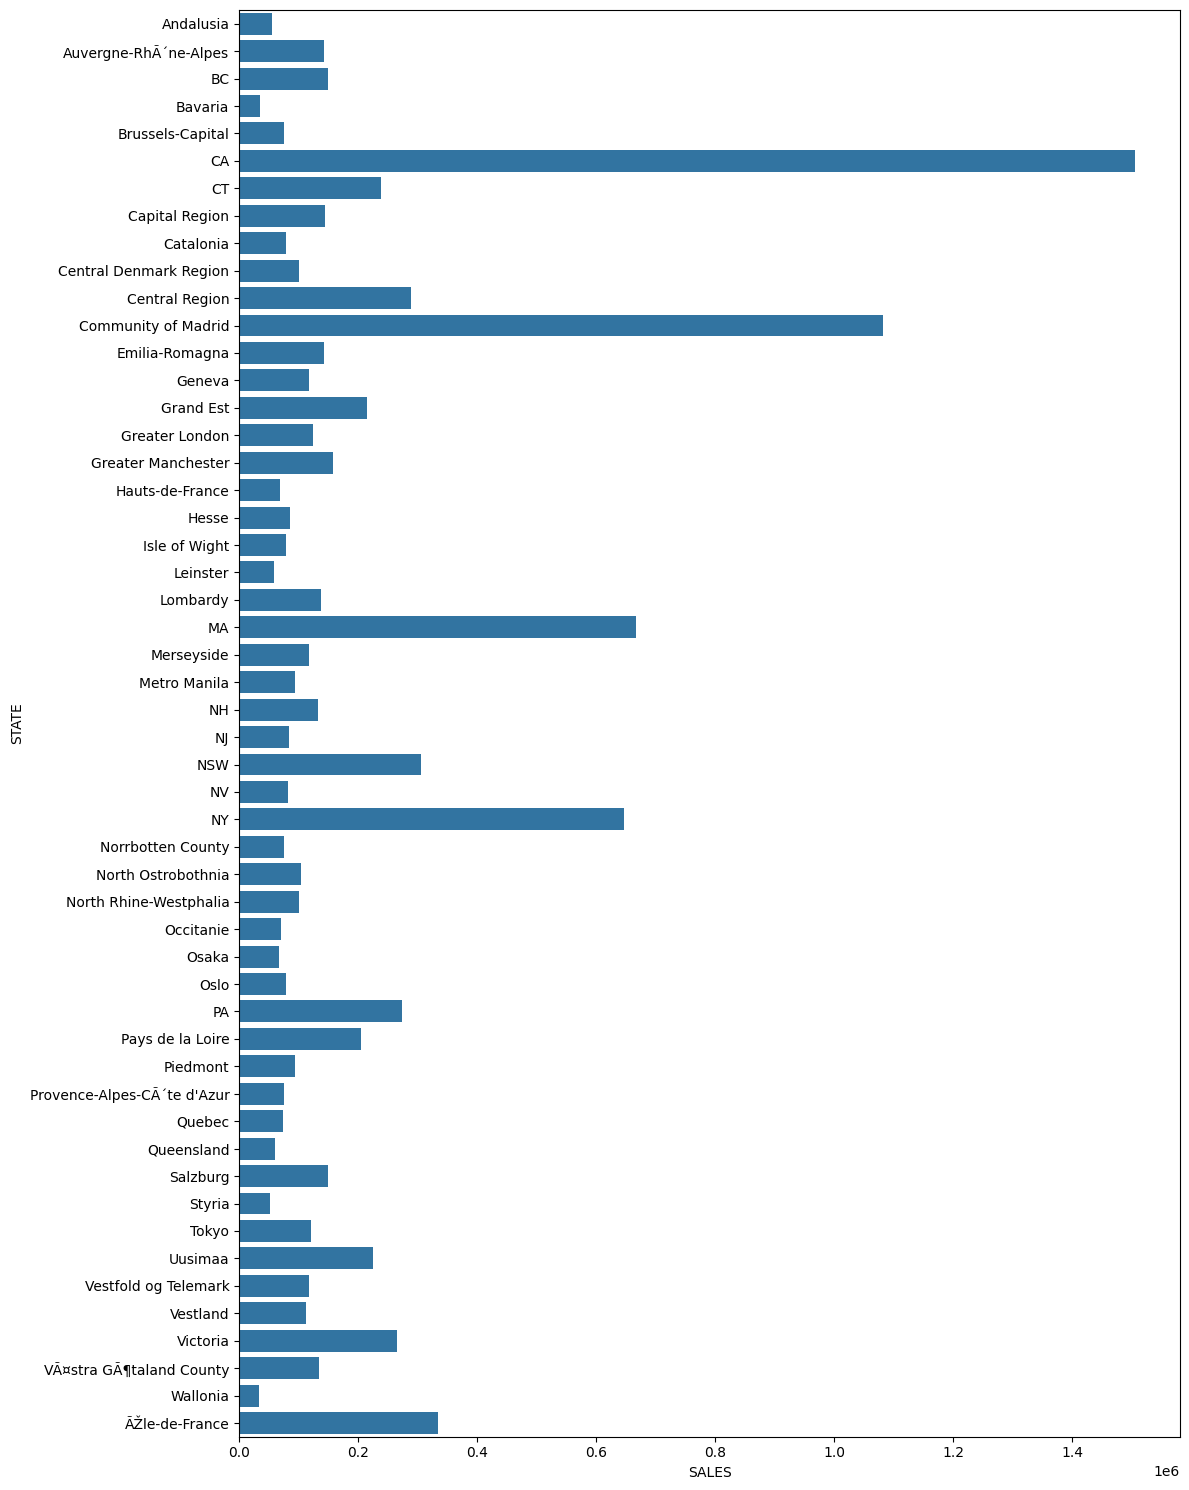

In [117]:
# fig1, ax1 = plt.subplots()
# receita1 = agrupado_por_estado['SALES']
# estado = agrupado_por_estado['STATE']
# ax1.bar(estado, receita1)
# ax1.set_xticks(range(len(estado)))
# ax1.set_xticklabels(estado, rotation=60)
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 15))
sns.barplot(x="SALES", y="STATE", data=agrupado_por_estado, ax=ax)
plt.tight_layout()
plt.show()


-- podemos notar que CA - NY - COMMUNITY OF MADRID  - MA sao os estados que mais vendem produtos 

In [118]:
# agrupa por linha de produto e calcula total de quantidade e receita
for categoria in df["PRODUCTLINE"]:
    agrupado_por_cidade = df.groupby("CITY")["SALES"].sum().reset_index()
# display(agrupado_por_cidade)
porcentagem_cidade = agrupado_por_cidade
porcentagem_cidade['PERCENTAGE'] = (agrupado_por_cidade['SALES']/agrupado_por_cidade['SALES'].sum()) * 100
display(porcentagem_cidade)

,CITY,SALES,PERCENTAGE
0,Aaarhus,100595.55,1.002684
1,Allentown,122138.14,1.217409
2,Barcelona,78411.86,0.781568
3,Bergamo,137955.72,1.375071
4,Bergen,111640.28,1.112772
...,...,...,...
68,Toulouse,70488.44,0.702592
69,Tsawassen,74634.85,0.743921
70,Vancouver,75238.92,0.749942
71,Versailles,64834.32,0.646235


In [148]:
df.to_excel("porcentagem_cidade.xlsx", index=False)

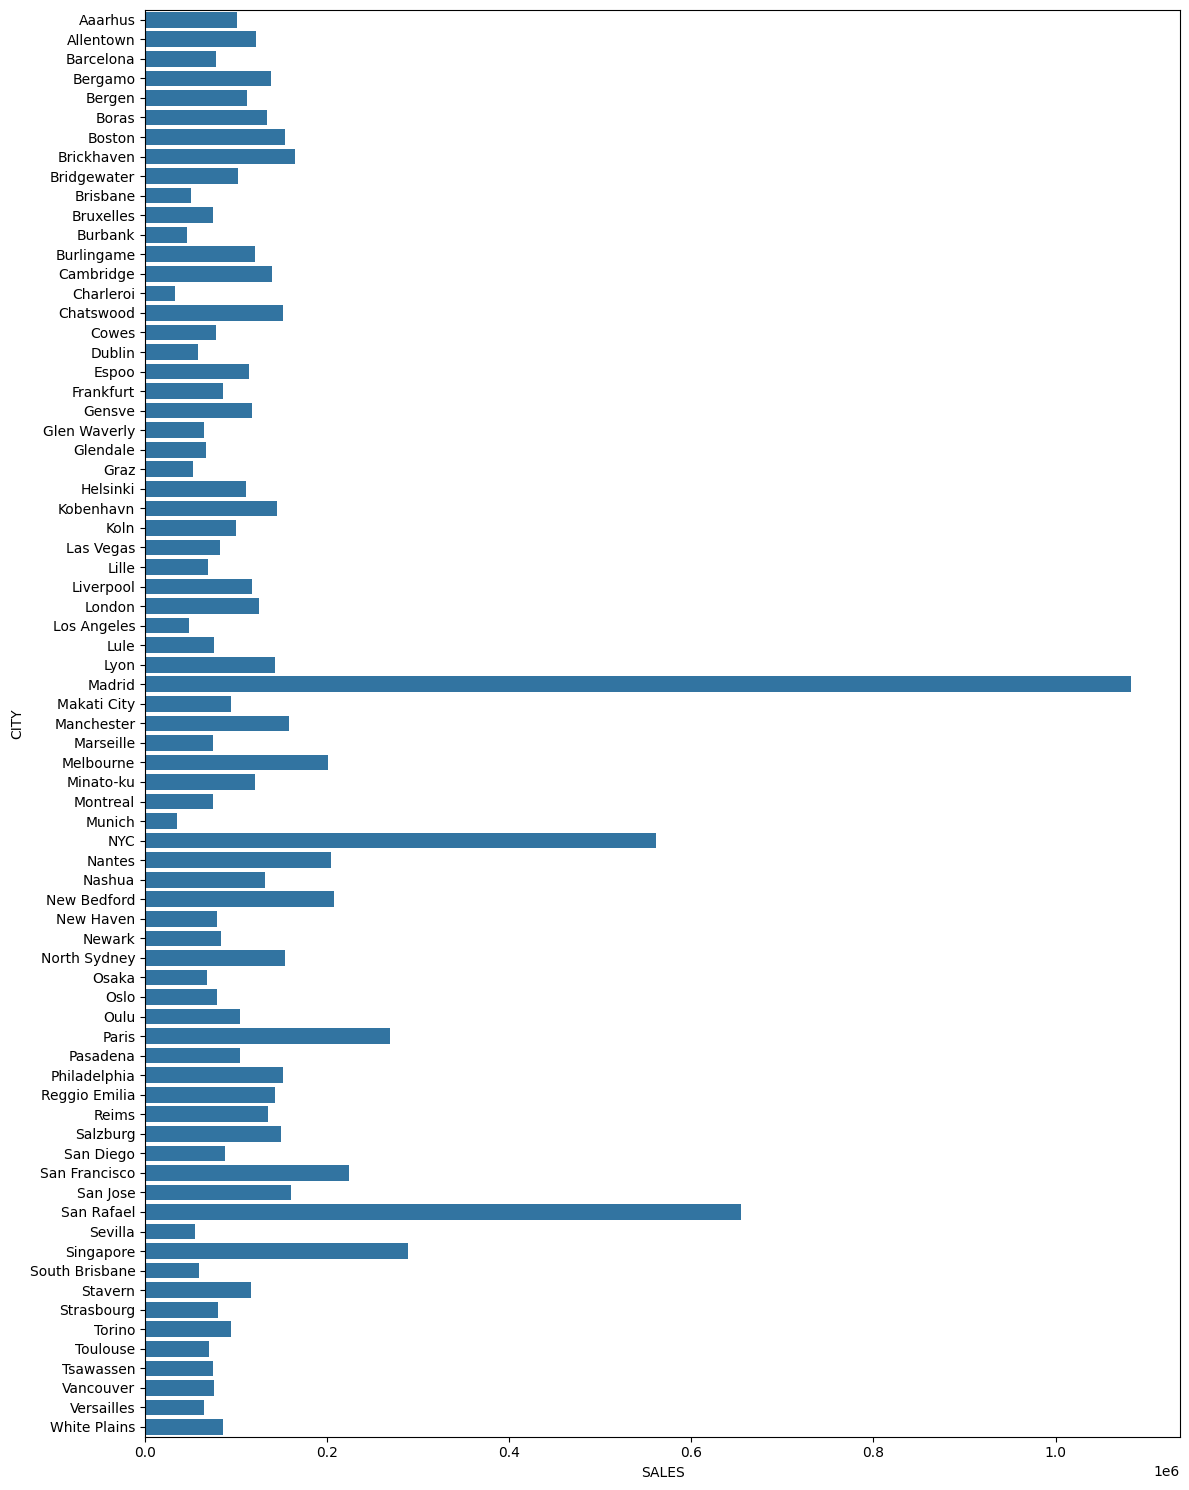

In [119]:

fig, ax = plt.subplots(figsize=(12, 15))
sns.barplot(x="SALES", y="CITY", data=agrupado_por_cidade, ax=ax)
plt.tight_layout()
plt.show()

# entao...

é notavel que MADRID  - nyc - san rafael - SAO CIDADES QUE MAIS VENDE

In [120]:
tabela_categoria = df.pivot_table(values='SALES', index='CITY', columns='PRODUCTLINE', aggfunc='sum', fill_value=0)
display(tabela_categoria)


PRODUCTLINE,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars
CITY,,,,,,,
Aaarhus,79375.64,0.00,0.00,1753.06,7146.23,9588.82,2731.80
Allentown,36144.20,33805.30,10235.43,0.00,5351.61,27800.52,8801.08
Barcelona,5324.40,10881.75,16179.15,28254.46,0.00,0.00,17772.10
Bergamo,5535.25,0.00,67756.64,10754.92,0.00,0.00,53908.91
Bergen,60795.84,30524.29,3957.05,0.00,0.00,0.00,16363.10
...,...,...,...,...,...,...,...
Toulouse,20743.56,0.00,19072.64,21782.88,0.00,0.00,8889.36
Tsawassen,2992.00,4177.49,25510.07,22919.06,0.00,0.00,19036.23
Vancouver,27160.93,0.00,0.00,0.00,0.00,32493.22,15584.77


In [149]:
df.to_excel("tabela_categoria.xlsx", index=False)

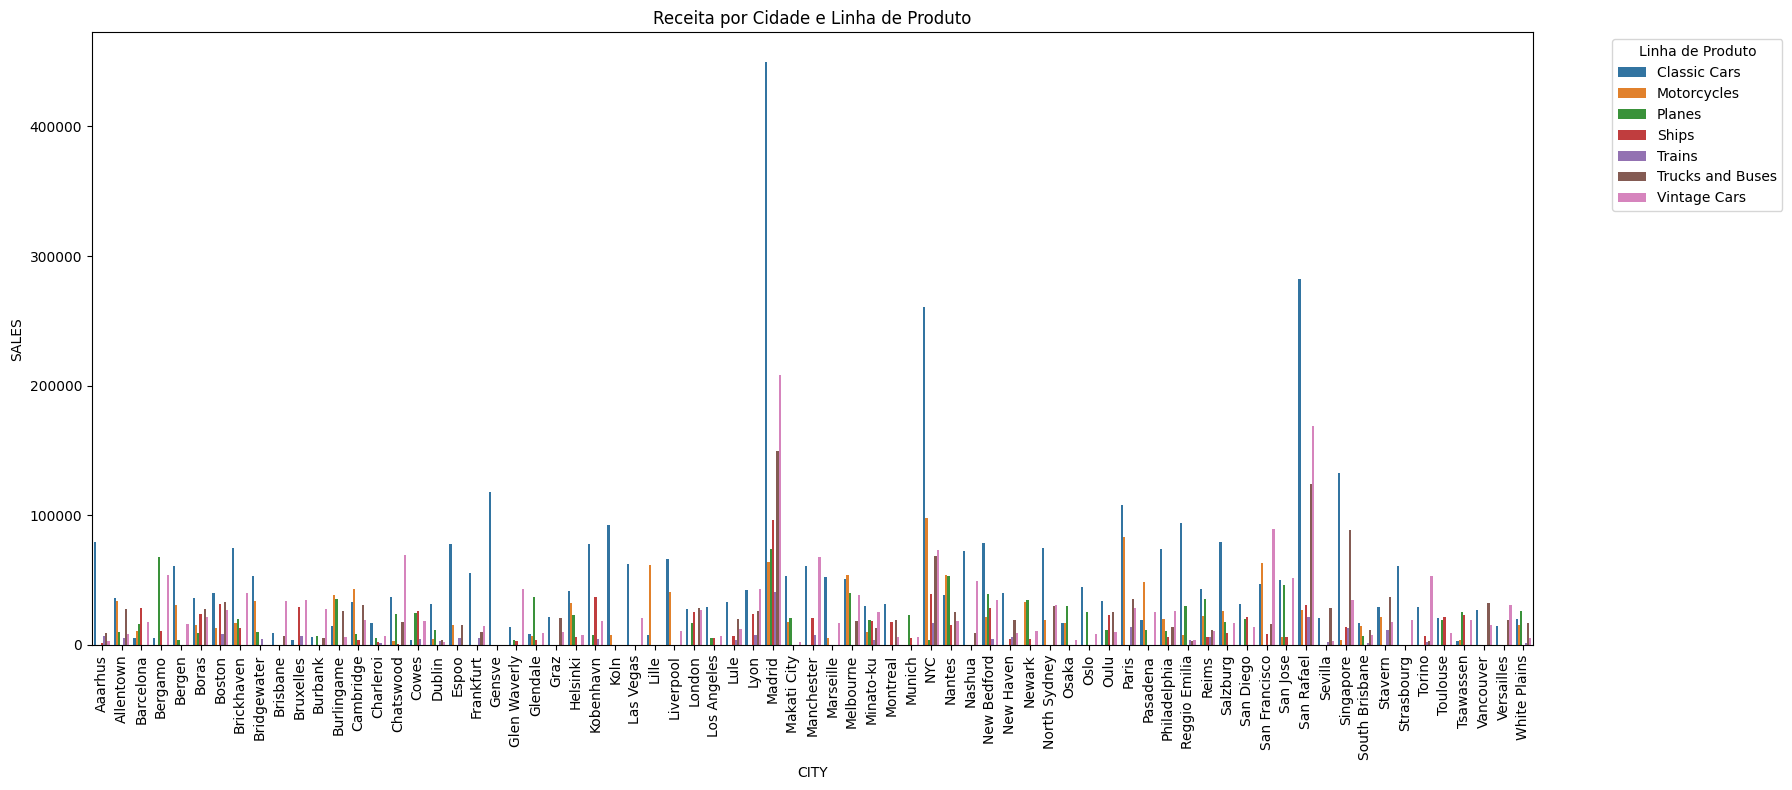

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# Resetando o índice para plotar com seaborn
df_melted = tabela_categoria.reset_index().melt(id_vars='CITY', var_name='PRODUCTLINE', value_name='SALES')

plt.figure(figsize=(18, 8))
sns.barplot(data=df_melted, x='CITY', y='SALES', hue='PRODUCTLINE')

plt.title('Receita por Cidade e Linha de Produto')
plt.xticks(rotation=90)
plt.legend(title='Linha de Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# entaoo 
-- É possivel notar que cada cidade as vendas dos classic cars e vintage cars se sobressaem


In [122]:
porcentagem = agrupado_ordenado.groupby('PRODUCTLINE')['SALES'].sum().reset_index()

# Calcular a soma total das vendas
total_sales = porcentagem['SALES'].sum()

# Adicionar uma coluna com a porcentagem de cada linha em relação ao total
porcentagem['PERCENTAGE'] = (porcentagem['SALES'] / total_sales) * 100

# Mostrar o dataframe com as porcentagens
display(porcentagem)

# Mostrar o total da receita
display(f'Total Revenue: ${total_sales:.2f}')

,PRODUCTLINE,SALES,PERCENTAGE
0,Classic Cars,3919615.66,39.068680
1,Motorcycles,1166388.34,11.625949
2,Planes,975003.57,9.718326
3,Ships,714437.13,7.121136
4,Trains,226243.47,2.255077
5,Trucks and Buses,1127789.84,11.241220
6,Vintage Cars,1903150.84,18.969613


'Total Revenue: $10032628.85'

In [137]:

vendas_mensais = df.pivot_table(values='SALES', index=['MONTH_ID',"YEAR_ID"], columns='PRODUCTLINE', aggfunc='sum', fill_value=0)
display(vendas_mensais)

PRODUCTLINE       Classic Cars  Motorcycles     Planes     Ships    Trains  \
MONTH_ID YEAR_ID                                                             
1        2003         41191.78         0.00       0.00      0.00   4933.55   
         2004        122791.55     41200.52   35453.54  29479.55   7582.86   
         2005        139087.23     39913.36   11262.27  31807.85   6510.17   
2        2003         20464.41     25783.76   39205.31  27050.38   4330.10   
         2004        133034.82     49066.50   37659.93  30611.52   4968.01   
         2005        146148.57     47951.42   31040.41  10586.06   7209.84   
3        2003        105026.68     12639.15       0.00      0.00      0.00   
         2004         81144.00         0.00       0.00  21576.79   9641.82   
         2005         91389.86     47830.83   79735.05  52765.15  12939.45   
4        2003         59873.60     23475.59   36563.34  27399.45   4756.47   
         2004         91815.89     36269.07   23032.84      0.00      0.00   
         2005        111562.51     59862.22   43763.59   6284.00      0.00   
5        2003         98179.48     22097.32       0.00      0.00      0.00   
         2004         83382.16     46848.95   40656.20  29421.29  10199.47   
         2005        184385.11     39389.70   34272.85  26735.01  10257.87   
6        2003         50256.79      2642.01   32115.65  29044.82  10071.06   
         2004         87163.19     47237.41   36650.28  24229.71      0.00   
7        2003         94055.58     37924.23       0.00      0.00      0.00   
         2004        151237.37     22774.00   40915.32  22532.62  10802.20   
8        2003         48406.61     44164.91   33938.33  25607.08   7374.94   
         2004        216895.82     62704.93   33413.68  26643.29   8793.18   
9        2003        137666.87      3155.58       0.00  20564.19   6034.52   
         2004         97006.21     42471.05   34785.62  25151.04   6445.32   
10       2003        241145.43     64235.65   69180.74  35980.37  10233.50   
         2004        223856.81     39413.96   37596.91  43811.37  15183.37   
11       2003        452924.37    109345.50   54133.27  79174.80  22523.40   
         2004        372231.89    151711.86  121130.70  63900.85  22271.23   
12       2003        135593.69     25431.88    7120.96      0.00   2544.75   
         2004        101697.38     20846.98   61376.78  24079.94  20636.39   

PRODUCTLINE       Trucks and Buses  Vintage Cars  
MONTH_ID YEAR_ID                                  
1        2003             36801.43      46826.84  
         2004              5152.00      74917.40  
         2005             36577.20      74385.34  
2        2003                 0.00      24002.23  
         2004             31036.91      25041.84  
         2005             37174.16      78075.72  
3        2003              9908.06      46931.01  
         2004             37389.90      55981.22  
         2005             14579.38      75023.04  
4        2003             28790.76      20750.34  
         2004                 0.00      55030.32  
         2005                 0.00      40160.97  
5        2003             25362.73      47033.58  
         2004             36181.14      26749.18  
         2005             89726.28      73094.24  
6        2003             17369.72      26582.51  
         2004             43407.79      47985.84  
7        2003             26099.98      29652.09  
         2004             38170.09      40712.49  
8        2003             15031.97      23285.46  
         2004             34911.32      78139.05  
9        2003             43506.30      53045.90  
         2004             41791.35      73100.32  
10       2003             46912.03     100603.25  
         2004             76901.54     116160.29  
11       2003            127062.92     184673.40  
         2004            123811.14     233990.34  
12       2003             43584.03      47601.15  
         2004             60549.71      83615.48

In [150]:
df.to_excel("vendas_mensais.xlsx", index=False)

-- podemos concluir que os carros classicos sao os mais vendidos nos estados e se sobressaem nos numeros de vendas seguido dos carros vintages
-- podemos notar que CA - NY - COMMUNITY OF MADRID  - MA sao os estados que mais vendem produtos 
-- é notavel que MADRID  - nyc - san rafael - SAO CIDADES QUE MAIS VENDE


<Figure size 1400x800 with 0 Axes>

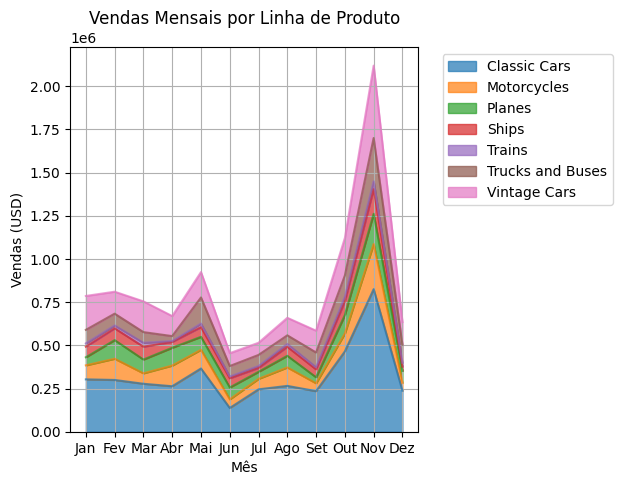

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados (usando sua tabela como base)
vendas_mensais = df.pivot_table(values='SALES', 
                               index='MONTH_ID', 
                               columns='PRODUCTLINE', 
                               aggfunc='sum', 
                               fill_value=0)

# 2. Análise para todos os produtos (visão geral)
plt.figure(figsize=(14, 8))
vendas_mensais.plot(kind='area', stacked=True, alpha=0.7)
plt.title('Vendas Mensais por Linha de Produto')
plt.xlabel('Mês')
plt.ylabel('Vendas (USD)')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

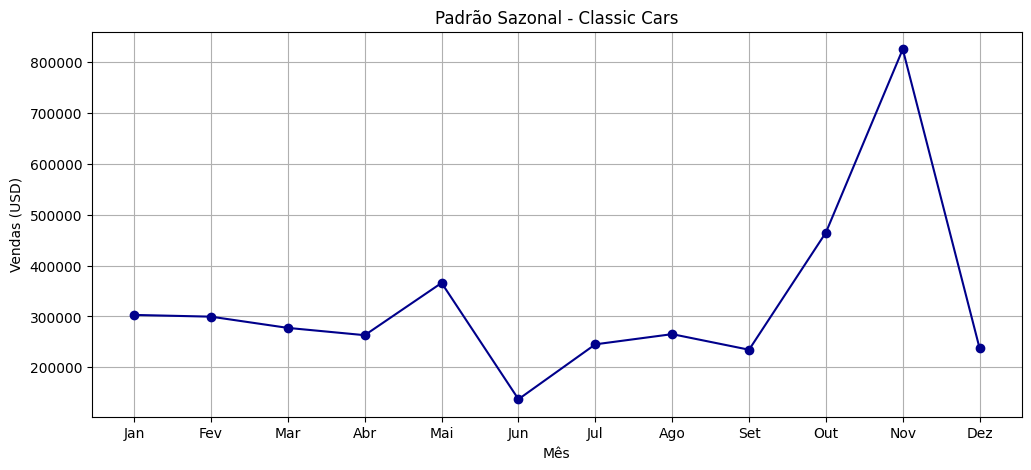

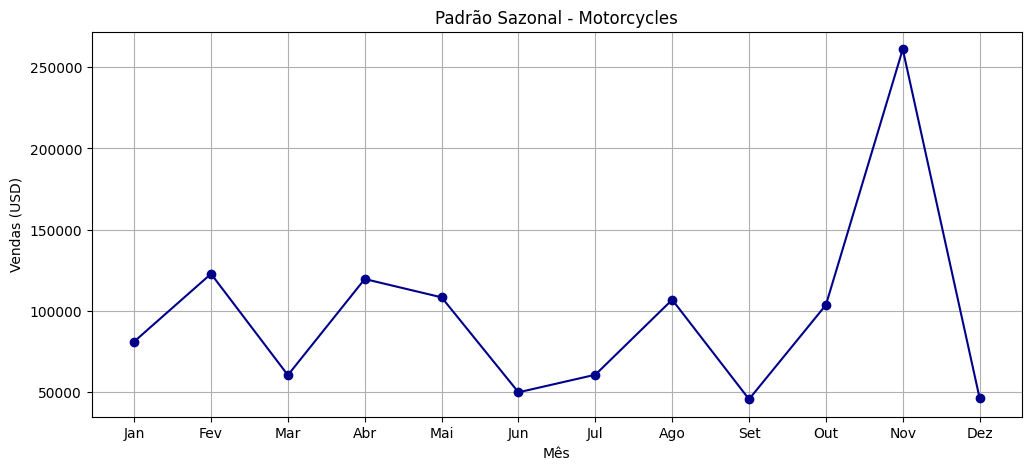

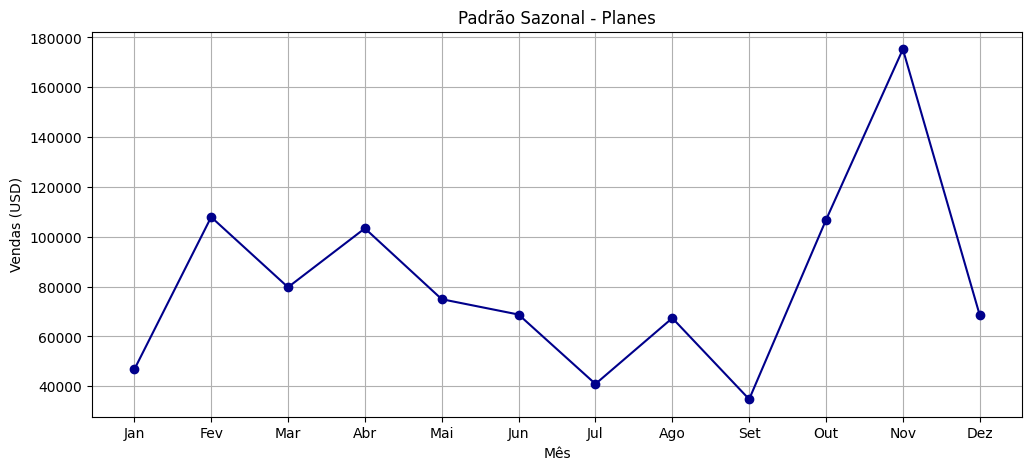

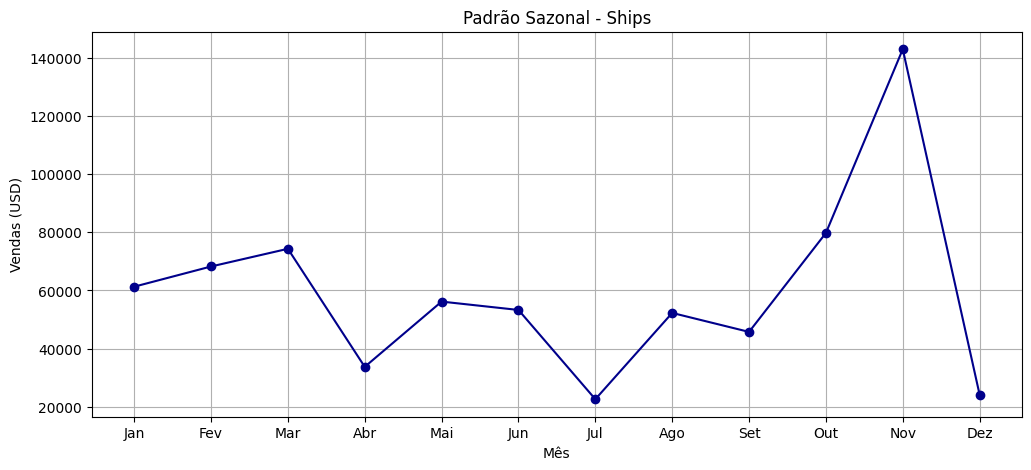

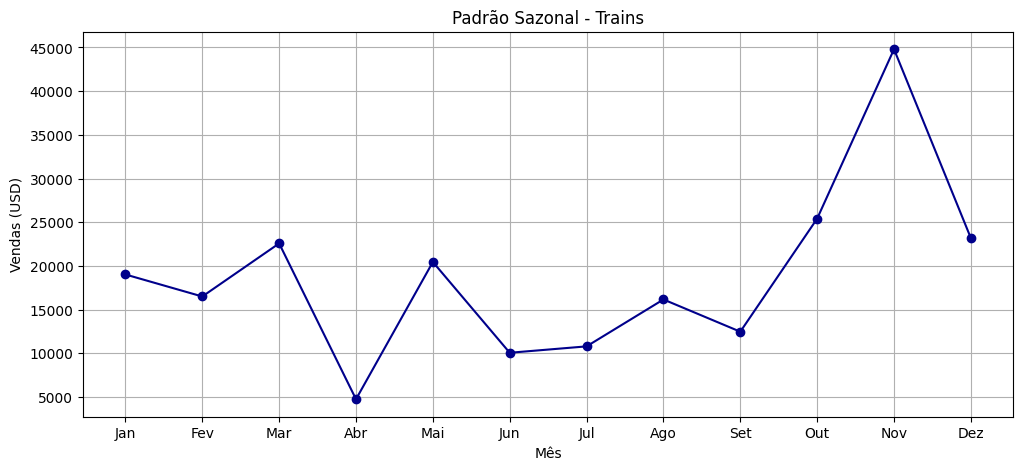

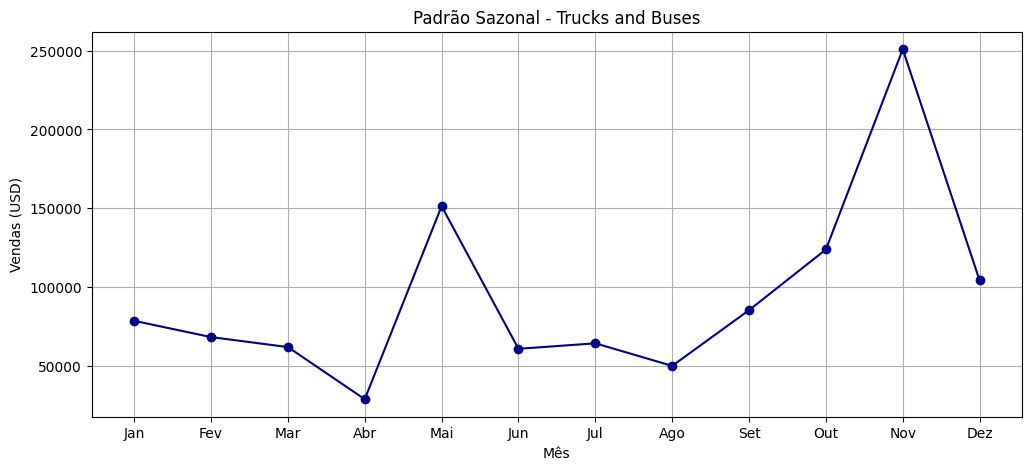

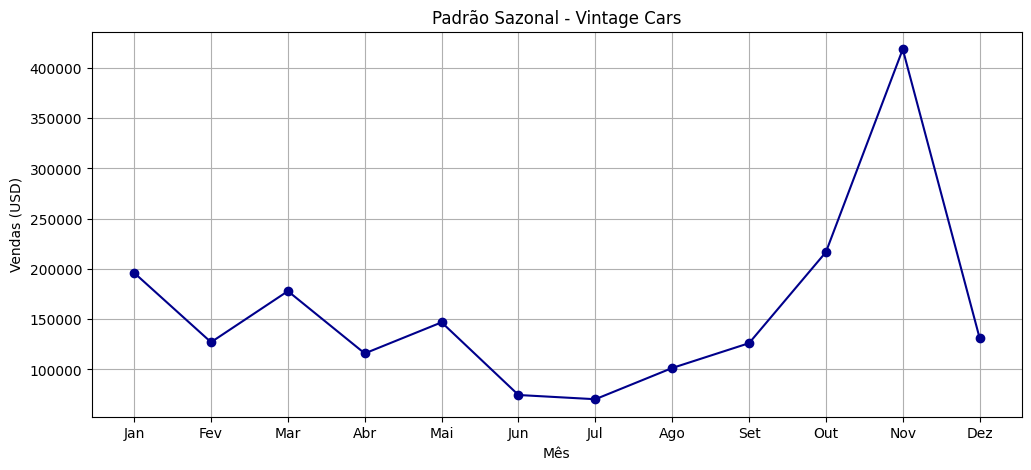

In [125]:
# 3. Análise individual por produto
for produto in vendas_mensais.columns:
    plt.figure(figsize=(12, 5))
    vendas_mensais[produto].plot(marker='o', color='darkblue')
    plt.title(f'Padrão Sazonal - {produto}')
    plt.xlabel('Mês')
    plt.ylabel('Vendas (USD)')
    plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                            'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
    plt.grid(True)
    plt.show()

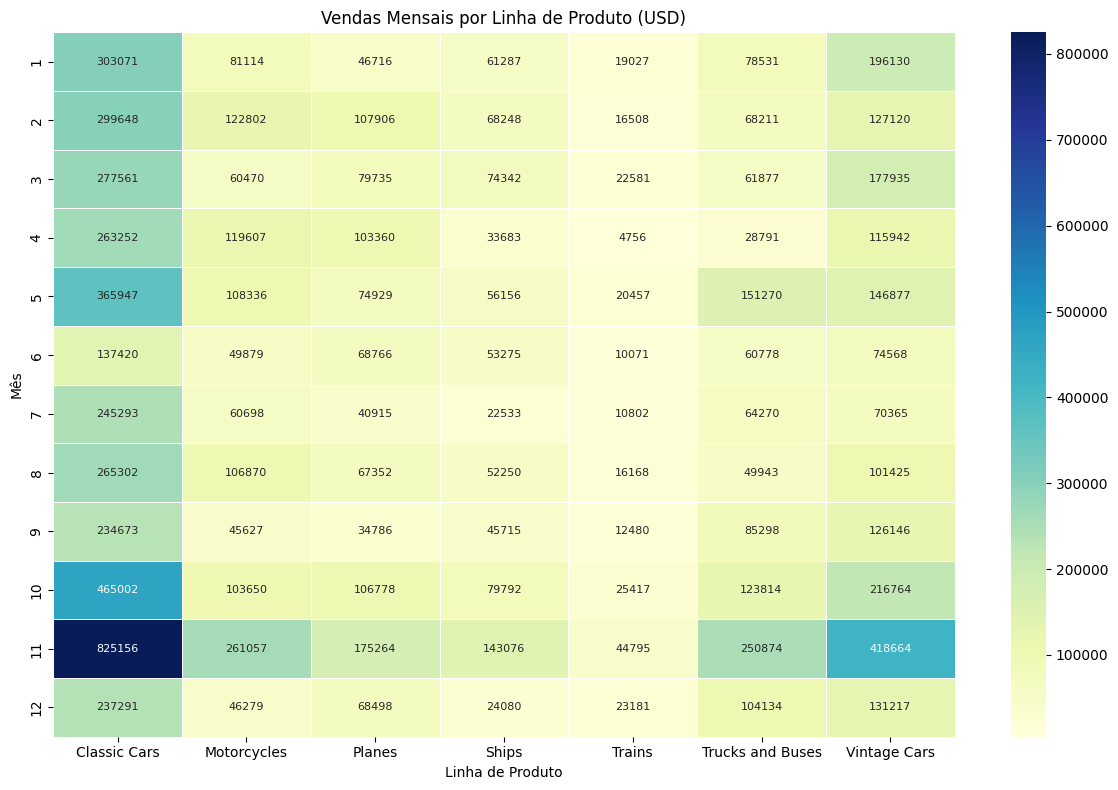

In [126]:
# 4. Heatmap de sazonalidade
plt.figure(figsize=(12, 8))
sns.heatmap(vendas_mensais, annot=True, fmt=".0f", cmap="YlGnBu", 
           linewidths=.5, annot_kws={"size": 8})
plt.title("Vendas Mensais por Linha de Produto (USD)")
plt.xlabel("Linha de Produto")
plt.ylabel("Mês")
plt.tight_layout()
plt.show()

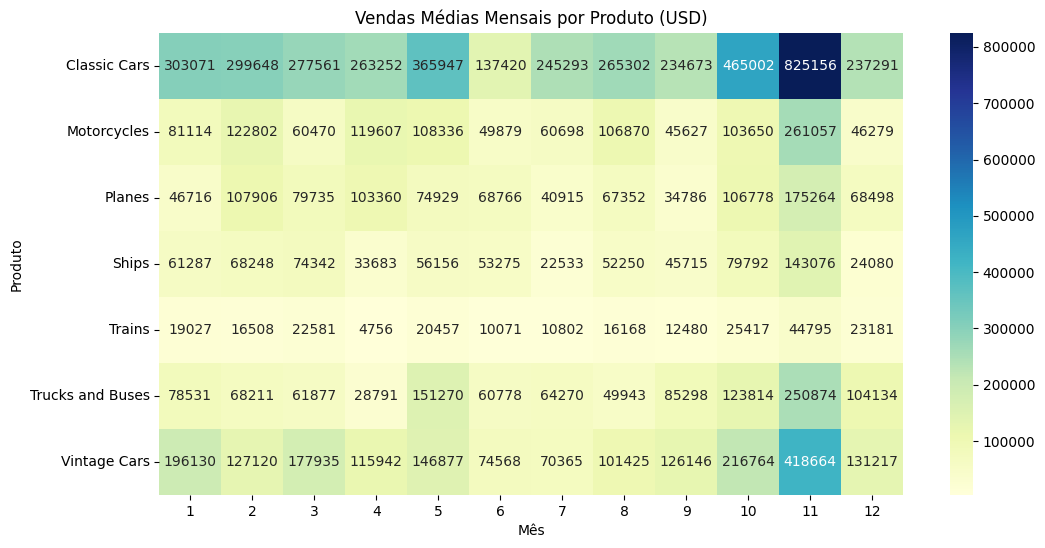

In [127]:
import seaborn as sns

# Calcular a componente sazonal média para cada mês
seasonal_avg = vendas_mensais.groupby('MONTH_ID').mean()

plt.figure(figsize=(12, 6))
sns.heatmap(seasonal_avg.T, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Vendas Médias Mensais por Produto (USD)")
plt.xlabel("Mês")
plt.ylabel("Produto")
plt.show()

In [128]:
# Mês com maior venda histórica para cada produto
picos = vendas_mensais.groupby('MONTH_ID').mean().idxmax()
print("Meses de pico por produto:")
print(picos)

Meses de pico por produto:
PRODUCTLINE
Classic Cars        11
Motorcycles         11
Planes              11
Ships               11
Trains              11
Trucks and Buses    11
Vintage Cars        11
dtype: int64


In [ ]:
totais = vendas_mensais

display(totais)

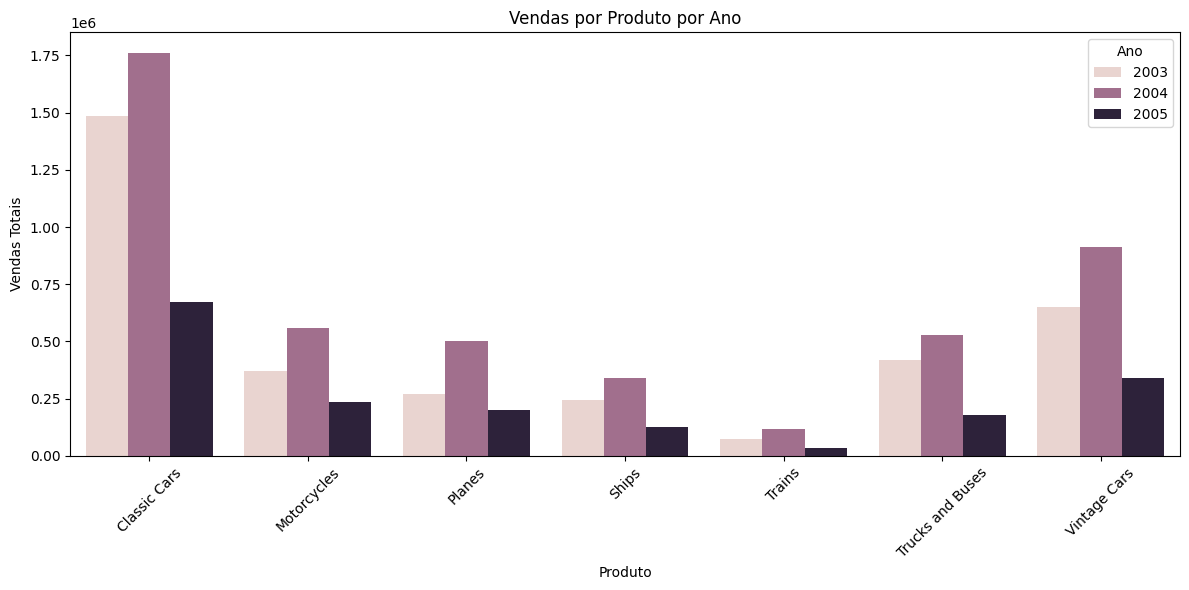

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Resetar índice para ter YEAR_ID como coluna
df_reset = totais.reset_index()

# Agrupar por produto e ano somando as vendas
df_ano_produto = df_reset.groupby(["YEAR_ID"]).sum(numeric_only=True)

# Voltar a transformar para formato longo 
df_long = df_reset.melt(id_vars=["YEAR_ID", "MONTH_ID"], 
                        var_name="Produto", 
                        value_name="Vendas")

# Agrupar novamente para somar as vendas anuais por produto
df_vendas_por_ano = df_long.groupby(["YEAR_ID", "Produto"])["Vendas"].sum().reset_index()

# Criar gráfico
plt.figure(figsize=(12, 6)) # DIMENSOES DA FIGURA 
sns.barplot(data=df_vendas_por_ano, x="Produto", y="Vendas", hue="YEAR_ID") # GRAFICO DE BARRAS (BARPLOT) 
plt.title("Vendas por Produto por Ano") # TITULO
plt.xlabel("Produto") # EIXO X
plt.ylabel("Vendas Totais") # EIXO Y
plt.xticks(rotation=45) 
plt.legend(title="Ano") 
plt.tight_layout()
plt.show() 


c:\Users\amand\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\amand\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\amand\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


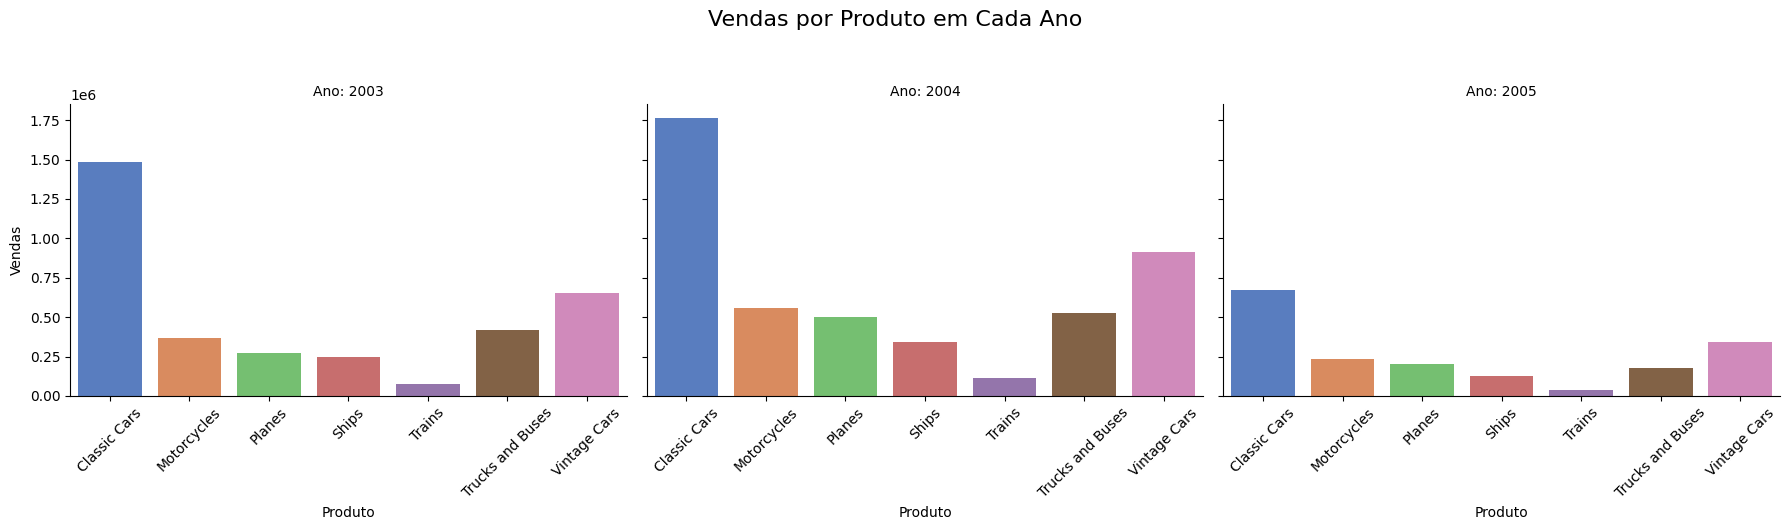

In [141]:
# Usar o mesmo DataFrame transformado em formato longo
g = sns.FacetGrid(df_vendas_por_ano, col="YEAR_ID", height=5, aspect=1.2)
g.map_dataframe(sns.barplot, x="Produto", y="Vendas", palette="muted")
g.set_titles("Ano: {col_name}")
g.set_xticklabels(rotation=45)
g.fig.suptitle("Vendas por Produto em Cada Ano", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()


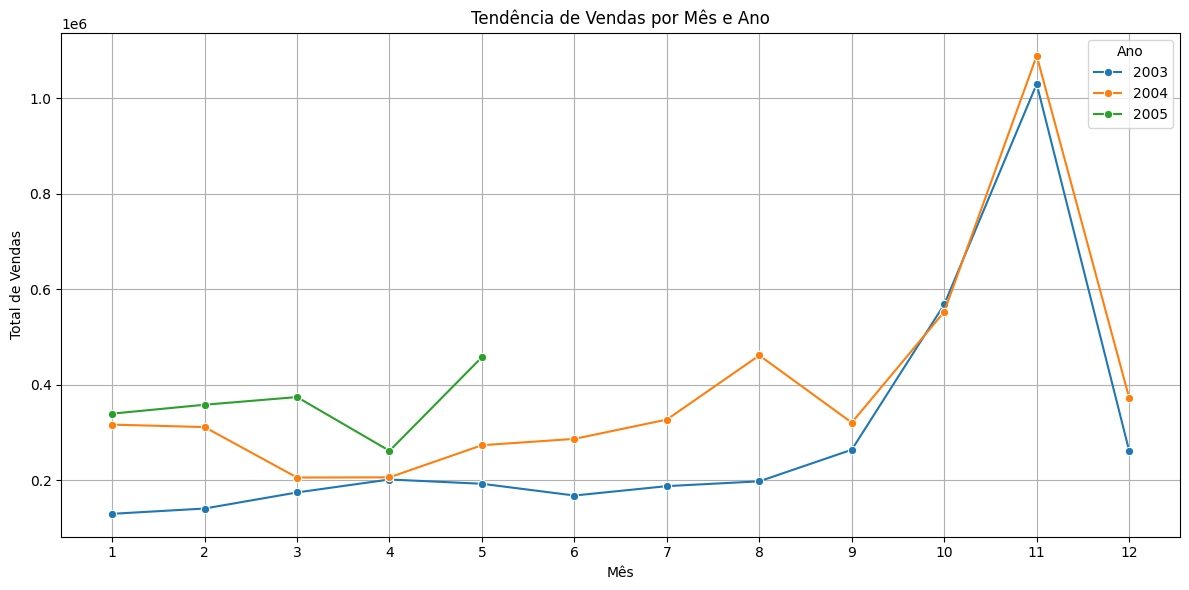

In [143]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Resetar índice da tabela pivot (caso ainda não tenha feito)
df_reset = vendas_mensais.reset_index()

# Transformar de wide para long
df_long = df_reset.melt(id_vars=["MONTH_ID", "YEAR_ID"],
                        var_name="PRODUCTLINE",
                        value_name="SALES")

# Agrupar por MÊS e ANO (somando todas as linhas de produto)
df_trend = df_long.groupby(["YEAR_ID", "MONTH_ID"])["SALES"].sum().reset_index()

# Plotar gráfico de linha: mês no eixo X, vendas no eixo Y, uma linha por ano
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trend, x="MONTH_ID", y="SALES", hue="YEAR_ID", marker="o", palette="tab10")

plt.title("Tendência de Vendas por Mês e Ano")
plt.xlabel("Mês")
plt.ylabel("Total de Vendas")
plt.xticks(range(1, 13))  # Meses de 1 a 12
plt.legend(title="Ano")
plt.grid(True)
plt.tight_layout()
plt.show()


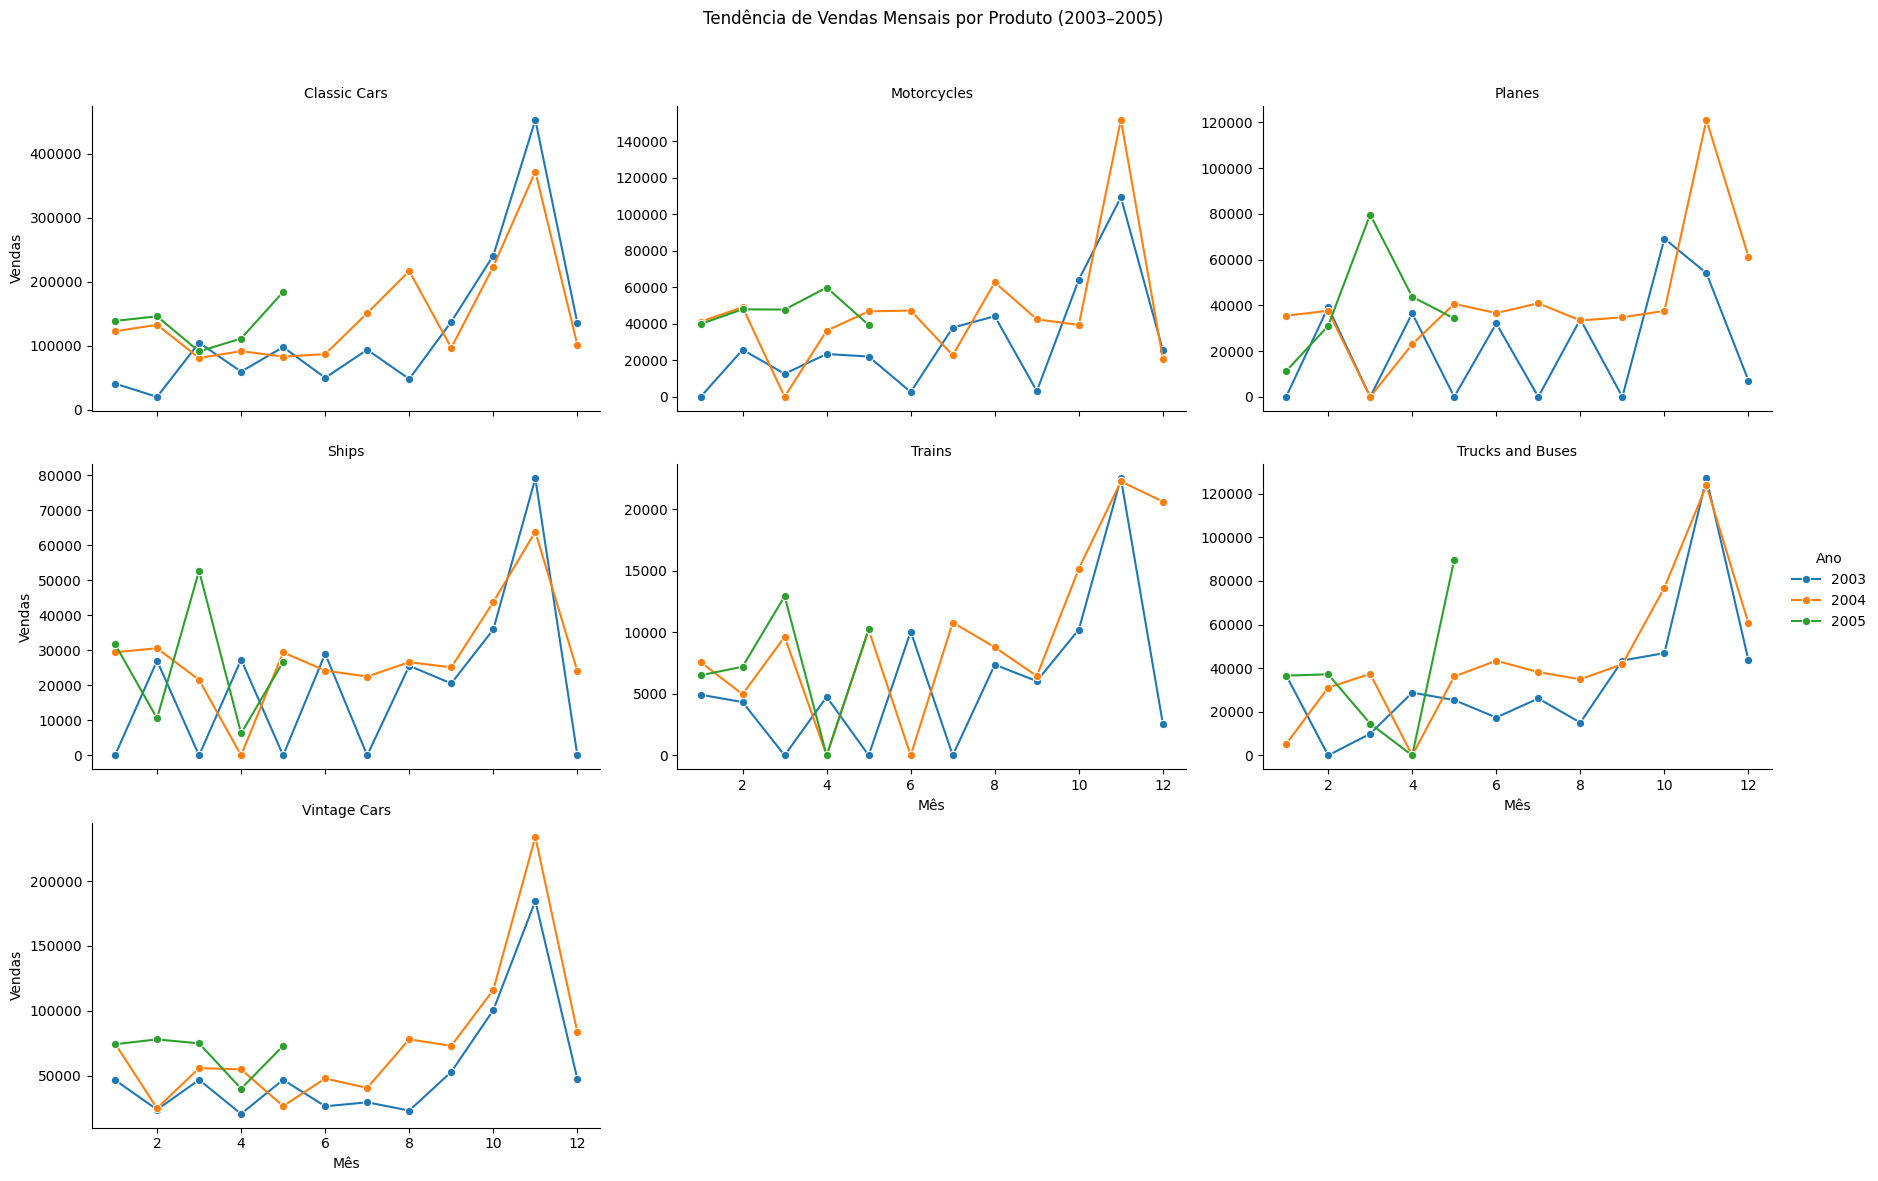

In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Resetar o índice da tabela pivot
df_reset = vendas_mensais.reset_index()

# Transformar de wide para long
df_long = df_reset.melt(id_vars=["MONTH_ID", "YEAR_ID"],
                        var_name="PRODUCTLINE",
                        value_name="SALES")

# Criar gráfico com vários subgráficos: um por produto
g = sns.FacetGrid(df_long, col="PRODUCTLINE", col_wrap=3, height=4, aspect=1.5, sharey=False)
g.map_dataframe(sns.lineplot, x="MONTH_ID", y="SALES", hue="YEAR_ID", marker="o", palette="tab10")

# Ajustar o layout
g.set_titles("{col_name}")
g.set_axis_labels("Mês", "Vendas")
g.add_legend(title="Ano")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Tendência de Vendas Mensais por Produto (2003–2005)")
plt.show()



In [166]:
menores_vendas = porcentagem_cidade

menores_vendas.nsmallest(34, 'SALES')


,CITY,SALES,PERCENTAGE
14,Charleroi,33440.10,0.333313
41,Munich,34993.92,0.348801
11,Burbank,46084.64,0.459348
31,Los Angeles,48048.46,0.478922
9,Brisbane,50218.51,0.500552
23,Graz,52263.90,0.520939
62,Sevilla,54723.62,0.545456
17,Dublin,57756.43,0.575686
64,South Brisbane,59469.12,0.592757
21,Glen Waverly,64591.46,0.643814
